=== SMALL INPUT SOURCE DATA ===
   Size_SqFt  Bedrooms  Age_Years  Price_USD
0       1200         2         10     210000
1       1800         3          5     290000
2       2400         4          2     380000
3       1500         3         20     230000
4       3000         4          1     450000

=== STEP-BY-STEP MATHEMATICAL TRAINING LOG ===
[Step 1] Created Design Matrix (X). Shape: (5, 4)
[[1.0e+00 1.2e+03 2.0e+00 1.0e+01]
 [1.0e+00 1.8e+03 3.0e+00 5.0e+00]
 [1.0e+00 2.4e+03 4.0e+00 2.0e+00]
 [1.0e+00 1.5e+03 3.0e+00 2.0e+01]
 [1.0e+00 3.0e+03 4.0e+00 1.0e+00]]
------------------------------------------------------------
[Step 2] Transposed Design Matrix (X^T). Shape: (4, 5)
[[1.0e+00 1.0e+00 1.0e+00 1.0e+00 1.0e+00]
 [1.2e+03 1.8e+03 2.4e+03 1.5e+03 3.0e+03]
 [2.0e+00 3.0e+00 4.0e+00 3.0e+00 4.0e+00]
 [1.0e+01 5.0e+00 2.0e+00 2.0e+01 1.0e+00]]
------------------------------------------------------------
[Step 3] Computed (X^T * X). Shape: (4, 4)
[[5.00 9,900.00 16.00 38.00]
 [

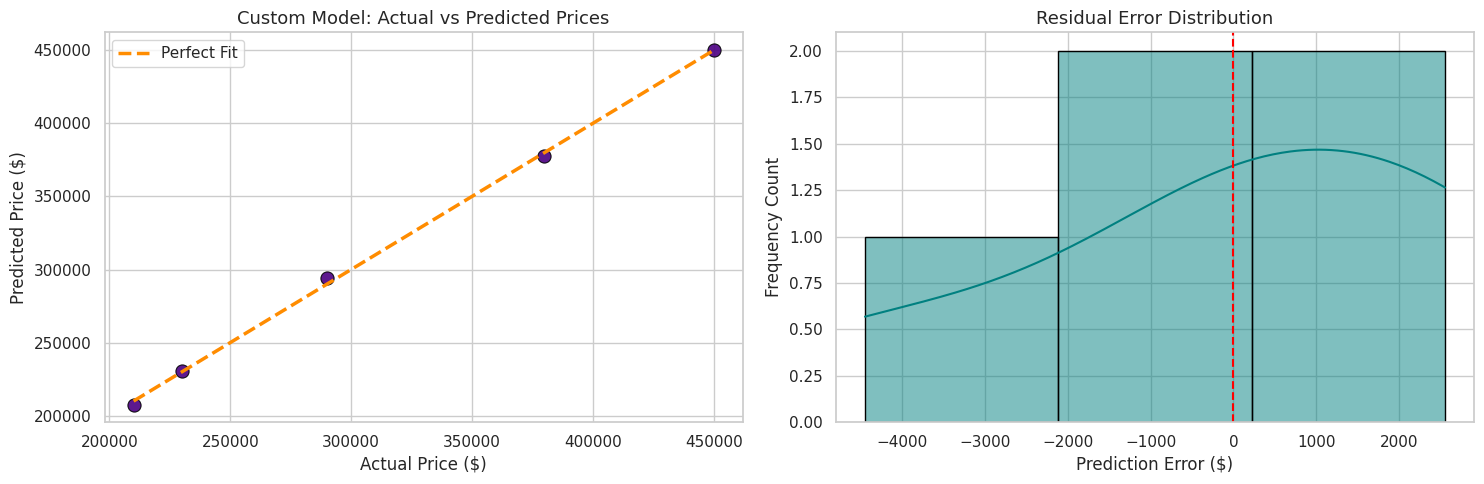

In [15]:
# ==========================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# Set style for nice charts
sns.set_theme(style="whitegrid")

# ==========================================
# STEP 2: CREATE A SMALL, READABLE DATASET
# ==========================================
# Clean data for 5 houses
# Features: [Size_SqFt, Bedrooms, Age_Years]
X = np.array([
    [1200, 2, 10],
    [1800, 3, 5],
    [2400, 4, 2],
    [1500, 3, 20],
    [3000, 4, 1]
])

# Target values: House Prices in USD
y = np.array([210000, 290000, 380000, 230000, 450000])

# Display the source data clearly
df = pd.DataFrame(X, columns=['Size_SqFt', 'Bedrooms', 'Age_Years'])
df['Price_USD'] = y
print("=== SMALL INPUT SOURCE DATA ===")
print(df)
print("=" * 60 + "\n")

# ==========================================
# STEP 3: THE STEP-BY-STEP REGRESSION CLASS
# ==========================================
class ExplanatoryLinearRegression:
    def __init__(self):
        self.beta = None
        self.intercept_ = None
        self.coef_ = None

    def fit(self, X, y):
        print("=== STEP-BY-STEP MATHEMATICAL TRAINING LOG ===")

        # 1. Add Intercept Column (A column of 1s)
        ones = np.ones((X.shape[0], 1))
        X_design = np.hstack((ones, X))
        print(f"[Step 1] Created Design Matrix (X). Shape: {X_design.shape}")
        print(X_design)
        print("-" * 60)

        # 2. Transpose Matrix
        X_transpose = X_design.T
        print(f"[Step 2] Transposed Design Matrix (X^T). Shape: {X_transpose.shape}")
        print(X_transpose)
        print("-" * 60)

        # 3. Compute (X^T * X)
        XTX = X_transpose.dot(X_design)
        print(f"[Step 3] Computed (X^T * X). Shape: {XTX.shape}")
        print(np.array2string(XTX, formatter={'float_kind': lambda x: f"{x:,.2f}"}))
        print("-" * 60)

        # 4. Compute Inverse of (X^T * X)
        XTX_inverse = np.linalg.inv(XTX)
        print(f"[Step 4] Computed Inverse Matrix (X^T * X)^(-1). Shape: {XTX_inverse.shape}")
        print(np.array2string(XTX_inverse, formatter={'float_kind': lambda x: f"{x:.4e}"}))
        print("-" * 60)

        # 5. Compute (X^T * y)
        XTy = X_transpose.dot(y)
        print(f"[Step 5] Computed Product Vector (X^T * y). Shape: {XTy.shape}")
        print(np.array2string(XTy, formatter={'float_kind': lambda x: f"{x:,.2f}"}))
        print("-" * 60)

        # 6. Calculate Final Beta parameters
        self.beta = XTX_inverse.dot(XTy)
        print(f"[Step 6] Calculated Beta parameters: Beta = (X^T * X)^(-1) * (X^T * y)")
        print(f"Beta vector shape: {self.beta.shape}")
        print("-" * 60)

        # Extract individual parameters
        self.intercept_ = self.beta[0]
        print(self.intercept_)
        self.coef_ = self.beta[1:]
        print(self.coef_)

    def predict(self, X):
        return X.dot(self.coef_) + self.intercept_

# ==========================================
# STEP 4: TRAIN THE MODEL AND SHOW INTERMEDIATES
# ==========================================
custom_model = ExplanatoryLinearRegression()
custom_model.fit(X, y)

print("\n=== CUSTOM MODEL FINAL PARAMETERS ===")
print(f"Calculated Intercept (Beta_0) : ${custom_model.intercept_:.2f}")
print(f"Size Coefficient (Beta_1)     : {custom_model.coef_[0]:.2f}")
print(f"Bedrooms Coefficient (Beta_2) : {custom_model.coef_[1]:.2f}")
print(f"Age Coefficient (Beta_3)      : {custom_model.coef_[2]:.2f}")
print("=" * 60)

# ==========================================
# STEP 5: PREDICTION AND EVALUATION
# ==========================================
y_pred = custom_model.predict(X)

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("\n=== PERFORMANCE METRICS SUMMARY ===")
print(f"Mean Squared Error (MSE)        : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE)  : ${rmse:.2f}")
print(f"R-squared (R2 Score)            : {r2:.4f}")
print("-" * 60)

# ==========================================
# STEP 6: PLOT DIAGRAMS (RESTORED)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Actual vs. Predicted values
sns.scatterplot(x=y, y=y_pred, ax=axes[0], color='indigo', edgecolor='black', s=90, alpha=0.9)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], color='darkorange', linestyle='--', lw=2.5, label='Perfect Fit')
axes[0].set_title('Custom Model: Actual vs Predicted Prices', fontsize=13)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].legend()

# Plot B: Prediction Error Distribution
residuals = y - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='teal', edgecolor='black', bins=3)
axes[1].axvline(x=0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Residual Error Distribution', fontsize=13)
axes[1].set_xlabel('Prediction Error ($)')
axes[1].set_ylabel('Frequency Count')

plt.tight_layout()
plt.show()
